In [1]:
import sys
sys.path.append("./Main/src")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from models_cl import CollectiveLearningModel

<Axes: title={'center': '50 agents, 1225 ties'}>

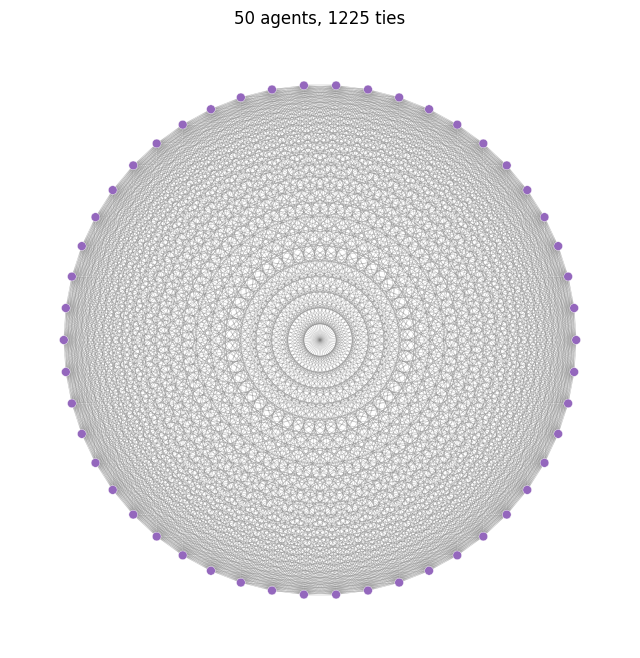

In [2]:
scenario = "consensus"

model = CollectiveLearningModel(
    n_agents=50,
    n_choices=6,
    network_type=scenario,
    alignment_max_time=10,
    consensus_threshold=1.0,
    seed=1
)

for agent in model.agents_list:
    agent.sampling = True

for i in range(1):
    model.step()

model.draw_network()

+----------------+-------------------------+
|    Property    |          Value          |
+----------------+-------------------------+
|    Agent ID    |            1            |
|    Strength    |          0.512          |
| Expertise List | [0.9504637  0.14415961] |
|   Experience   |          0.950          |
|     Choice     |            0            |
| Solved puzzles |            0            |
|    Targets     |            []           |
|    Guesses     |            []           |
+----------------+-------------------------+
+----------------+-------------------------+
|    Property    |          Value          |
+----------------+-------------------------+
|    Agent ID    |            2            |
|    Strength    |          0.949          |
| Expertise List | [0.31183145 0.42332645] |
|   Experience   |          0.423          |
|     Choice     |            1            |
| Solved puzzles |            0            |
|    Targets     |            []           |
|    Guess

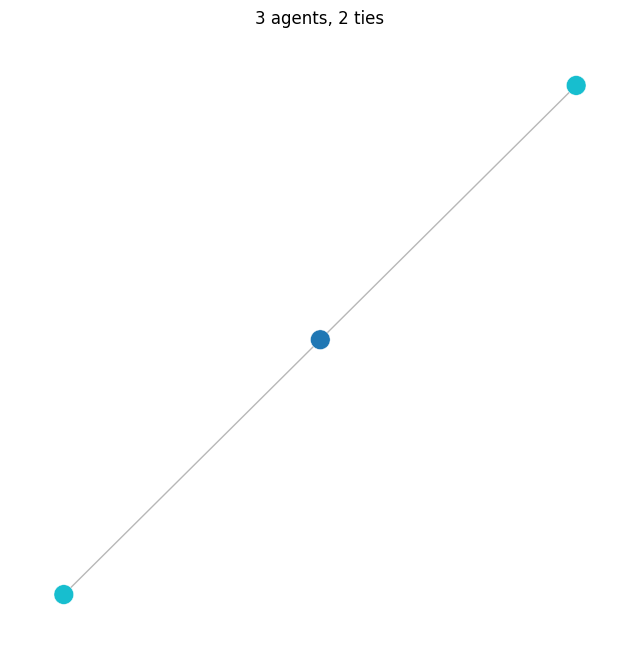

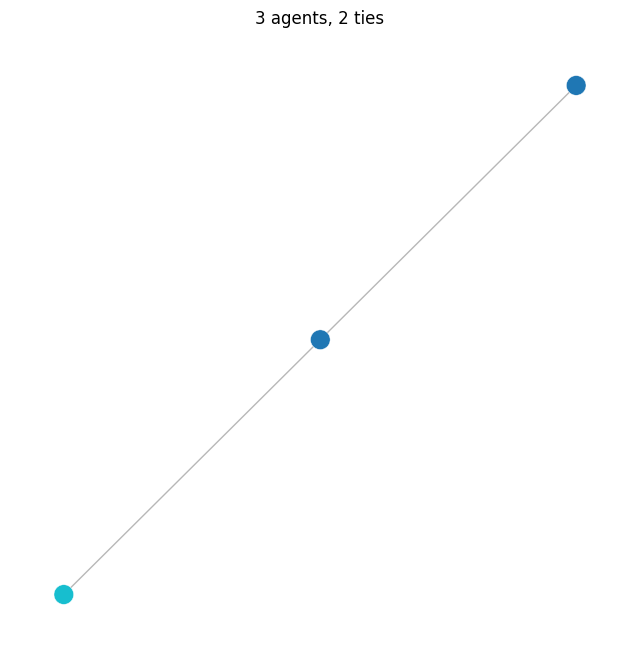

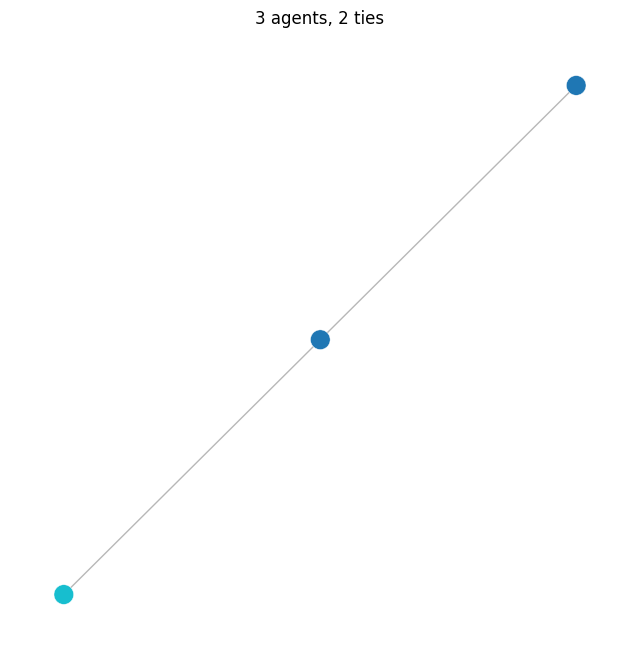

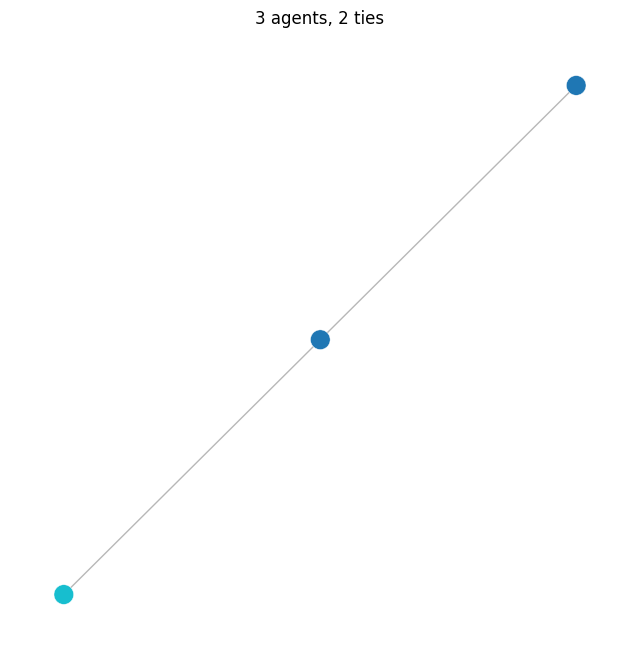

In [3]:
scenario = "consultative"
# scenario = "consensus"

model = CollectiveLearningModel(
    n_agents=3,
    n_choices=2,
    network_type=scenario,
    alignment_max_time=10,
    consensus_threshold=1.0,
    seed=1
)

for agent in model.agents_list:
    agent.sampling = False
    agent.debug_mode = True
    print(agent)

model.draw_network()

for i in range(3):
    print("="*80)
    print(f"Alignment round {i}") 
    model.alignment_phase()
    for agent in model.agents_list:
        print(agent)
    model.draw_network()

In [4]:
agent = model.agents_list[0]
model.grid.get_neighbors(agent.node)

In [5]:
list_df = []
NUM_ALL_CYCLE_ROUNDS = 1
NUM_SIMULATIONS = 30
NUM_ALLIGNMENT_ROUNDS = 10
NUM_CHOICES = 2
NUM_AGENTS = 50

scenario = "consensus"

#-------------------------------
# CONSENSUS WITH TEMPERATURE 0
#-------------------------------
for seed in range(NUM_SIMULATIONS):
    model = CollectiveLearningModel(
        n_agents=NUM_AGENTS,
        n_choices=NUM_CHOICES,
        network_type=scenario,
        alignment_max_time=NUM_ALLIGNMENT_ROUNDS,
        consensus_threshold=1.0,
        seed=seed
    )

    for i in range(NUM_ALL_CYCLE_ROUNDS):
        model.step()

    df = model.datacollector.get_model_vars_dataframe() 
    df["Seed"] = seed
    df["Structure"] = "Consensus (temperature=0)"
    list_df.append(df)

#-------------------------------
# CONSENSUS WITH TEMPERATURE 1
#-------------------------------
for seed in range(NUM_SIMULATIONS):
    model = CollectiveLearningModel(
        n_agents=NUM_AGENTS,
        n_choices=NUM_CHOICES,
        network_type=scenario,
        alignment_max_time=NUM_ALLIGNMENT_ROUNDS,
        consensus_threshold=1.0,
        seed=seed
    )

    for agent in model.agents_list:
        agent.sampling = True

    for i in range(NUM_ALL_CYCLE_ROUNDS):
        model.step()

    df = model.datacollector.get_model_vars_dataframe() 
    df["Seed"] = seed
    df["Structure"] = "Consensus (temperature=1)"
    list_df.append(df)

#-------------------------------
# CONSULTATIVE
#-------------------------------
scenario = "consultative"

for seed in range(NUM_SIMULATIONS):
    model = CollectiveLearningModel(
        n_agents=NUM_AGENTS,
        n_choices=NUM_CHOICES,
        network_type=scenario,
        alignment_max_time=NUM_ALLIGNMENT_ROUNDS,
        consensus_threshold=1.0,
        seed=seed
    )

    for agent in model.agents_list:
        agent.sampling = True

    for i in range(NUM_ALL_CYCLE_ROUNDS):
        model.step()

    df = model.datacollector.get_model_vars_dataframe() 
    df["Seed"] = seed
    df["Structure"] = "Consultative"
    list_df.append(df)

#-------------------------------
# AUTOCRATIC
#-------------------------------
scenario = "autocratic"

for seed in range(NUM_SIMULATIONS):
    model = CollectiveLearningModel(
        n_agents=NUM_AGENTS,
        n_choices=NUM_CHOICES,
        network_type=scenario,
        alignment_max_time=NUM_ALLIGNMENT_ROUNDS,
        consensus_threshold=1.0,
        seed=seed
    )

    model.temperature = 0.2

    for agent in model.agents_list:
        agent.sampling = True

    for i in range(NUM_ALL_CYCLE_ROUNDS):
        model.step()

    df = model.datacollector.get_model_vars_dataframe() 
    df["Seed"] = seed
    df["Structure"] = "Autocratic"
    list_df.append(df)

df = pd.concat(list_df, ignore_index=True)

In [6]:
df.head(2)

,Scenario,Round,Alignment_round,Total_Puzzles,Total_Time,Mean_Puzzles_Solved,Consensus,Seed,Structure
0,consensus,0,1,0,0,0.0,1.0,0,Consensus (temperature=0)
1,consensus,0,1,0,0,0.0,1.0,1,Consensus (temperature=0)


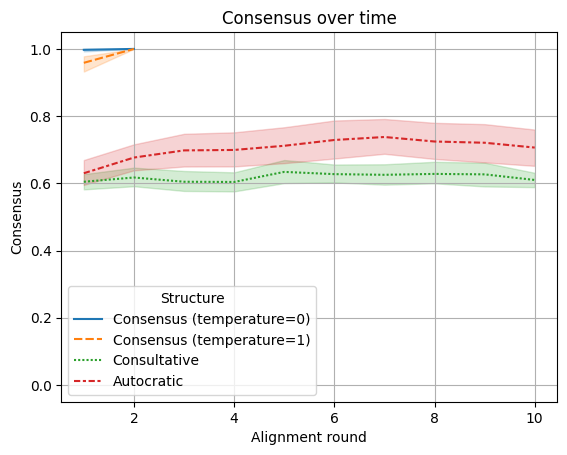

In [7]:
fig, ax = plt.subplots()

sns.lineplot(
    x="Alignment_round",
    y="Consensus",
    hue="Structure", style="Structure",
    data=df, ax=ax,
    errorbar=("ci", 95),
    # err_style="bars"
)

ax.set_title("Consensus over time")
ax.set_xlabel("Alignment round")
ax.set_ylabel("Consensus")
ax.set_ylim(-0.05, 1.05)
# ax.axhline(y=model.consensus_threshold, color="red", linestyle="--")
ax.grid()
plt.show()

In [ ]:
list_df = []
NUM_ALL_CYCLE_ROUNDS = 1
NUM_SIMULATIONS = 30
NUM_ALLIGNMENT_ROUNDS = 10
NUM_CHOICES = 2
NUM_AGENTS = 50

#-------------------------------
# AUTOCRATIC
#-------------------------------
scenario = "autocratic"

for seed in range(NUM_SIMULATIONS):
    model = CollectiveLearningModel(
        n_agents=NUM_AGENTS,
        n_choices=NUM_CHOICES,
        network_type=scenario,
        alignment_max_time=NUM_ALLIGNMENT_ROUNDS,
        consensus_threshold=1.0,
        seed=seed
    )

    model.temperature = 0.2

    model.agents_list[0].strength = 1.0
    model.agents_list[0].experience = 1.0
    model.agents_list[0].choice = 0
    model.agents_list[0].expertise_list = [1] + [0] * (model.n_choices - 1)

    for agent in model.agents_list:
        agent.sampling = True
        # print(agent)
        # agent.debug_mode = True

    for i in range(NUM_ALL_CYCLE_ROUNDS):
        model.step()

    df = model.datacollector.get_model_vars_dataframe() 
    df["Seed"] = seed
    df["Structure"] = "Autocratic"
    list_df.append(df)

df = pd.concat(list_df, ignore_index=True)

+----------------+--------+
|    Property    | Value  |
+----------------+--------+
|    Agent ID    |   1    |
|    Strength    | 1.000  |
| Expertise List | [1, 0] |
|   Experience   | 1.000  |
|     Choice     |   0    |
| Solved puzzles |   0    |
|    Targets     |   []   |
|    Guesses     |   []   |
+----------------+--------+
+----------------+-------------------------+
|    Property    |          Value          |
+----------------+-------------------------+
|    Agent ID    |            2            |
|    Strength    |          0.017          |
| Expertise List | [0.81327024 0.91275558] |
|   Experience   |          0.913          |
|     Choice     |            1            |
| Solved puzzles |            0            |
|    Targets     |            []           |
|    Guesses     |            []           |
+----------------+-------------------------+
+----------------+-------------------------+
|    Property    |          Value          |
+----------------+----------------

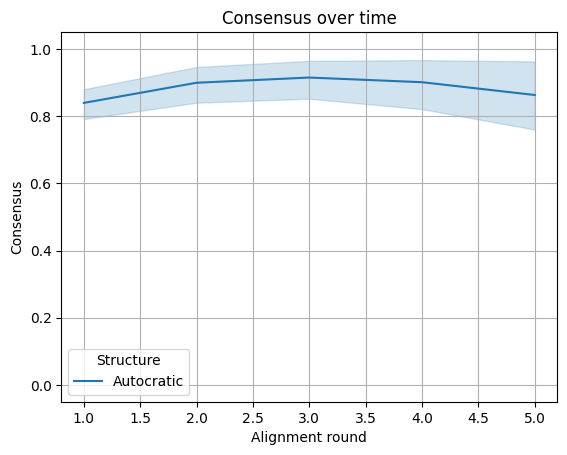

In [ ]:
fig, ax = plt.subplots()

sns.lineplot(
    x="Alignment_round",
    y="Consensus",
    hue="Structure", style="Structure",
    data=df, ax=ax,
    errorbar=("ci", 95),
    # err_style="bars"
)

ax.set_title("Consensus over time")
ax.set_xlabel("Alignment round")
ax.set_ylabel("Consensus")
ax.set_ylim(-0.05, 1.05)
# ax.axhline(y=model.consensus_threshold, color="red", linestyle="--")
ax.grid()
plt.show()